### import packages

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from stAggregator import stAggregator
from stAggregator import metrics
from stAggregator.data import process_adata, process_graph
from stAggregator.data import process_graph

In [4]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [5]:
def refine_label(adata, radius=50, key='label'):
    import ot
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values
    
    #calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')
           
    n_cell = distance.shape[0]
    
    for i in range(n_cell):
        vec  = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh+1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)
        
    new_type = [str(i) for i in list(new_type)]    
    #adata.obs['label_refined'] = np.array(new_type)
    
    return new_type

In [6]:
def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=42):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    adata.obsm['mclust_prob'] = np.array(res[-3])
    return adata

In [7]:
def mclust_R_smooth(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=42):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    adata.obsm['mclust_prob'] = np.array(res[-3])

    adata.obs['mclust'] = refine_label(adata, 50, key='mclust')
    
    return adata

In [8]:
def clear_fig(fig):
    if fig:
        fig.axes[0].set_xlabel(None)
        fig.axes[0].set_ylabel(None)
        fig.tight_layout()
    else:
        pass
    return fig

In [11]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # 

### load data

In [13]:
adata1 = sc.read_h5ad(f'./data/Mouse_intestine_VisiumHD_16um.h5ad')
adata1.obs_names_make_unique()
adata1.var_names_make_unique()
data_list = [adata1]
batch_key = 'batch'
batch_names = ['adata1']

adata = process_adata(data_list, batch_key=batch_key, batch_categories=batch_names, n_top_features=3000)
rad_cutoff_list = [100]
adata = process_graph(adata, data_list, rad_cutoff_list=rad_cutoff_list)
adata

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\anndata\_core\anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:87: ImplicitModificationWarning: Setting element `.obsm['feature_scale']` of view, initializing view as actual.
  adata.obsm['feature_scale'] = adata_scale.X


------Calculating spatial graph...


E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spatial_Net['Cell1'] = Spatial_Net['Cell1'].map(id_cell_trans)
E:\学习\6科研\论文\博士论文\stAggregator\stAggregator\stAggregator\data.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spatial_Net['Cell2'] = Spatial_Net['Cell2'].map(id_cell_trans)


The graph contains 702822 edges, 91033 cells.
7.7205 neighbors per cell on average.


AnnData object with n_obs × n_vars = 91033 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'adj'
    obsm: 'spatial', 'feature_scale'
    layers: 'counts'

### train

In [12]:
path_results = f'./log/integration/'
adata_stAggregator = stAggregator(adata=adata, max_iteration=800, outdir=path_results, h_dim=16,
                       batch_size=1024, early_stop=False, random_seed=42)

Epochs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [02:16<00:00, 15.19s/it, recon_loss_mse=56800.015, sl1_loss=97.823, sl2_loss=99.660, lr: 0.001]
2024-06-26 13:40:06,202 - root - INFO - Output dir: ./log/integration/


In [14]:
adata_stAggregator = sc.read_h5ad('./log/integration/adata_stAggregator.h5ad')
adata_stAggregator

AnnData object with n_obs × n_vars = 91033 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p'
    obsm: 'X_emb', 'X_stAggregator', 'feature_scale', 'spatial'
    layers: 'counts'

In [15]:
sc.pp.neighbors(adata_stAggregator, use_rep='X_stAggregator')

In [16]:
sc.tl.umap(adata_stAggregator)

#### Note, if an R environment already exists, you can simply point to and use it in jupyter
import os


os.environ['R_HOME']='/user/anaconda3/envs/STAX/1ib/R

In [21]:
mclust_R(adata_stAggregator, used_obsm='X_stAggregator', num_cluster=10)

fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 91033 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'batch', 'louvain', 'leiden', 'mclust'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'neighbors', 'umap', 'louvain', 'leiden', 'louvain_colors', 'leiden_colors'
    obsm: 'X_emb', 'X_stAggregator', 'feature_scale', 'spatial', 'X_umap', 'mclust_prob'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\10360\anaconda3\envs\CAMEX_t\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


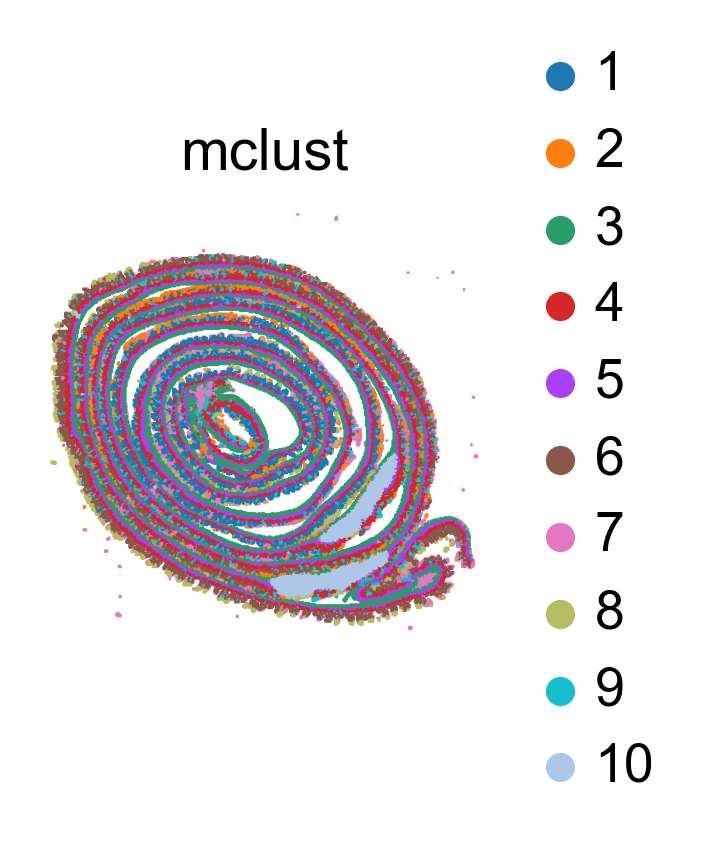

In [22]:
sc.pl.embedding(adata_stAggregator, basis='spatial', color=['mclust'], wspace=0.4)